# 02 ? Preprocessing
Effetti del filtraggio, R-peak detection e separazione della componente gravitazionale.

Il preprocessing ? la fase in cui trasformo segnali rumorosi in rappresentazioni pi? adatte all'analisi quantitativa. In un contesto riabilitativo questo passaggio ? delicato, perch? il movimento del paziente introduce artefatti che non devono essere confusi con variazioni fisiologiche reali.

L'idea ? isolare ci? che ha significato clinico: dall'ECG voglio una stima affidabile della dinamica cardiaca, mentre dall'accelerometro voglio separare postura e movimento attivo.


In [1]:
# Porto nel path la root del progetto per richiamare le stesse funzioni usate nella pipeline finale.
import sys; sys.path.insert(0, '..')
# Disattivo i warning per evitare che messaggi secondari coprano i risultati del preprocessing.
import warnings; warnings.filterwarnings('ignore')
# NumPy serve per gli indici temporali, mentre matplotlib e seaborn per confrontare prima e dopo del filtraggio.
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
# Carico funzioni di accesso ai dati e di segmentazione per mantenere coerenza tra notebook e codice sorgente.
from src.data_loader import load_patient, get_test_segments
from src.preprocessing import preprocess_ecg, preprocess_acc
from src.visualization import plot_rr_timeseries
# Mantengo uno stile grafico pulito perch? qui il confronto visivo ? parte della validazione metodologica.
sns.set_theme(style='whitegrid')
%matplotlib inline
# Uso sempre lo stesso paziente di esempio per rendere confrontabili exploration, preprocessing e feature extraction.
data = load_patient('001', 1)
# Tengo distinti ECG e ACC perch? subiranno trasformazioni diverse ma complementari.
ecg = data['ecg']; acc = data['acc']


## 1. ECG ? grezzo vs filtrato

Il confronto diretto tra ECG grezzo e filtrato serve a verificare che il filtro elimini deriva di baseline e rumore ad alta frequenza senza deformare eccessivamente il complesso QRS. Questo ? importante perch? un filtraggio troppo aggressivo migliorerebbe l'estetica del segnale ma peggiorerebbe la stima dei battiti.


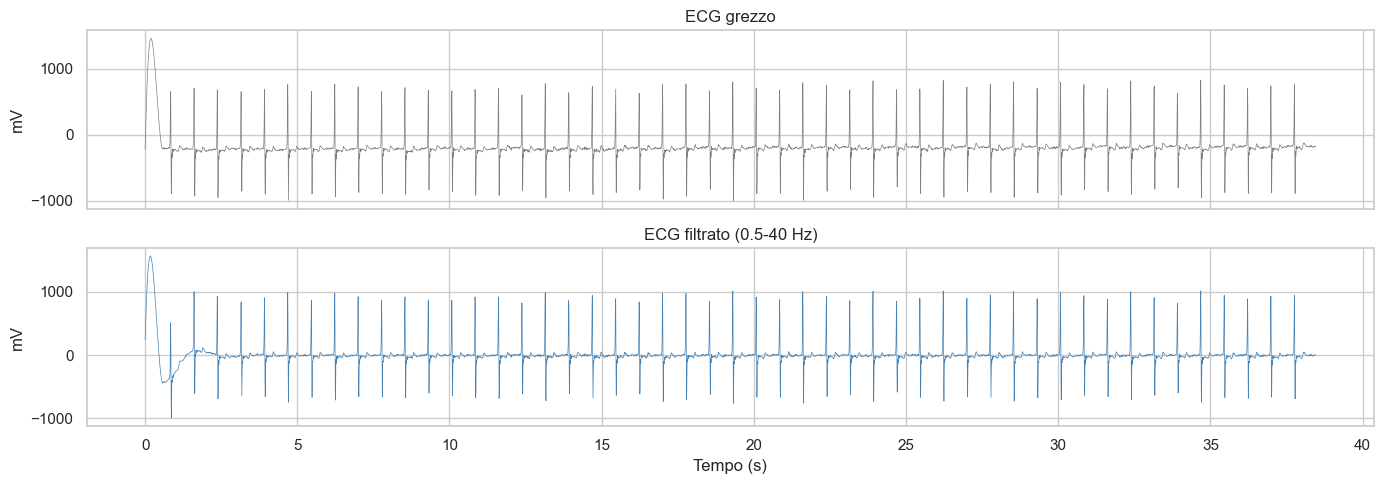

In [2]:
# Applico il preprocessing ECG per ottenere un segnale pi? pulito e adatto al rilevamento dei picchi R.
ecg_prep = preprocess_ecg(ecg['signal'], ecg['fs'])
# Costruisco l'asse temporale cos? la lettura del tracciato resta legata alla fisiologia e non ai soli campioni.
t = np.arange(5000) / ecg['fs']
# Metto grezzo e filtrato uno sotto l'altro per valutare quanto rumore viene rimosso.
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(t, ecg['signal'][:5000], lw=0.5, color='grey')
axes[0].set_title('ECG grezzo'); axes[0].set_ylabel('mV')
# Il segnale filtrato dovrebbe preservare la morfologia utile riducendo componenti che disturbano la detection dei battiti.
axes[1].plot(t, ecg_prep['filtered'][:5000], lw=0.5, color='steelblue')
axes[1].set_title('ECG filtrato (0.5-40 Hz)'); axes[1].set_ylabel('mV')
axes[1].set_xlabel('Tempo (s)')
# Stringo il layout per rendere immediato il confronto visivo campione per campione.
plt.tight_layout(); plt.show()


## 2. R-peak detection

Dopo il filtraggio verifico se i picchi R cadono nei punti attesi del complesso QRS. La bont? di questa fase ? cruciale perch? gli intervalli R-R sono la base per molte feature di variabilit? cardiaca, molto sensibili a falsi positivi o battiti persi.


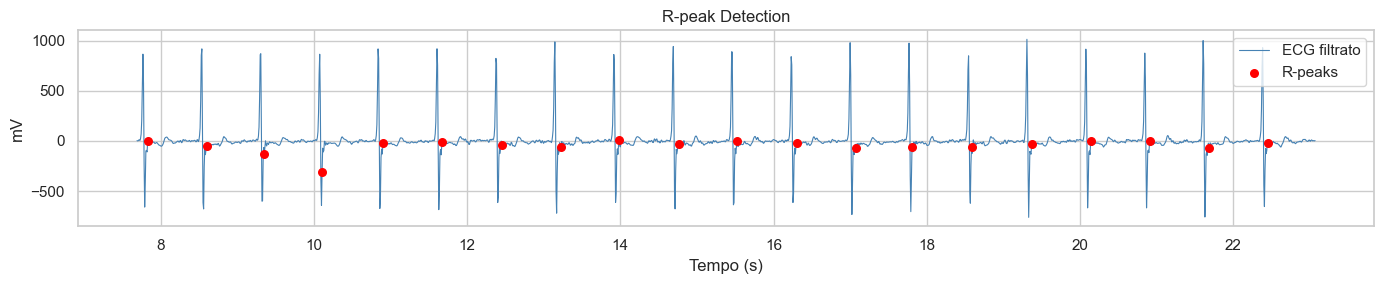

R-peaks totali: 7461
R-R intervals (clean): 7399
R-R mean: 752.1 ms  std: 33.5 ms


In [3]:
# Seleziono una finestra breve per controllare manualmente la precisione locale della detection.
seg_start = 1000; seg_end = 3000
# Anche qui trasformo i campioni in secondi per interpretare meglio la cadenza cardiaca.
t_seg = np.arange(seg_start, seg_end) / ecg['fs']
# Estraggo solo i picchi presenti nella finestra osservata, cos? il grafico resta leggibile.
rpeaks_seg = ecg_prep['rpeaks'][(ecg_prep['rpeaks'] >= seg_start) & (ecg_prep['rpeaks'] < seg_end)]
fig, ax = plt.subplots(figsize=(14, 3))
# Traccio il segnale filtrato perch? ? la base effettiva su cui il detector opera.
ax.plot(t_seg, ecg_prep['filtered'][seg_start:seg_end], lw=0.8, color='steelblue', label='ECG filtrato')
# Evidenzio i picchi R per verificare che cadano sui massimi fisiologicamente plausibili.
ax.scatter(rpeaks_seg / ecg['fs'], ecg_prep['filtered'][rpeaks_seg], color='red', s=30, zorder=5, label='R-peaks')
ax.set_title('R-peak Detection'); ax.set_xlabel('Tempo (s)'); ax.set_ylabel('mV')
ax.legend(); plt.tight_layout(); plt.show()
# Le statistiche finali riassumono se il numero di battiti e la variabilit? osservata hanno ordine di grandezza credibile.
print(f'R-peaks totali: {len(ecg_prep["rpeaks"])}')
print(f'R-R intervals (clean): {len(ecg_prep["rr_ms"])}')
print(f'R-R mean: {ecg_prep["rr_ms"].mean():.1f} ms  std: {ecg_prep["rr_ms"].std():.1f} ms')


## 3. R-R interval time series

La serie temporale degli intervalli R-R permette di osservare come la risposta cardiaca cambia tra le diverse fasi del protocollo. Mi interessa soprattutto capire se i cambiamenti coincidono con i test annotati, perch? questo suggerisce che il segnale stia catturando davvero l'adattamento allo sforzo.


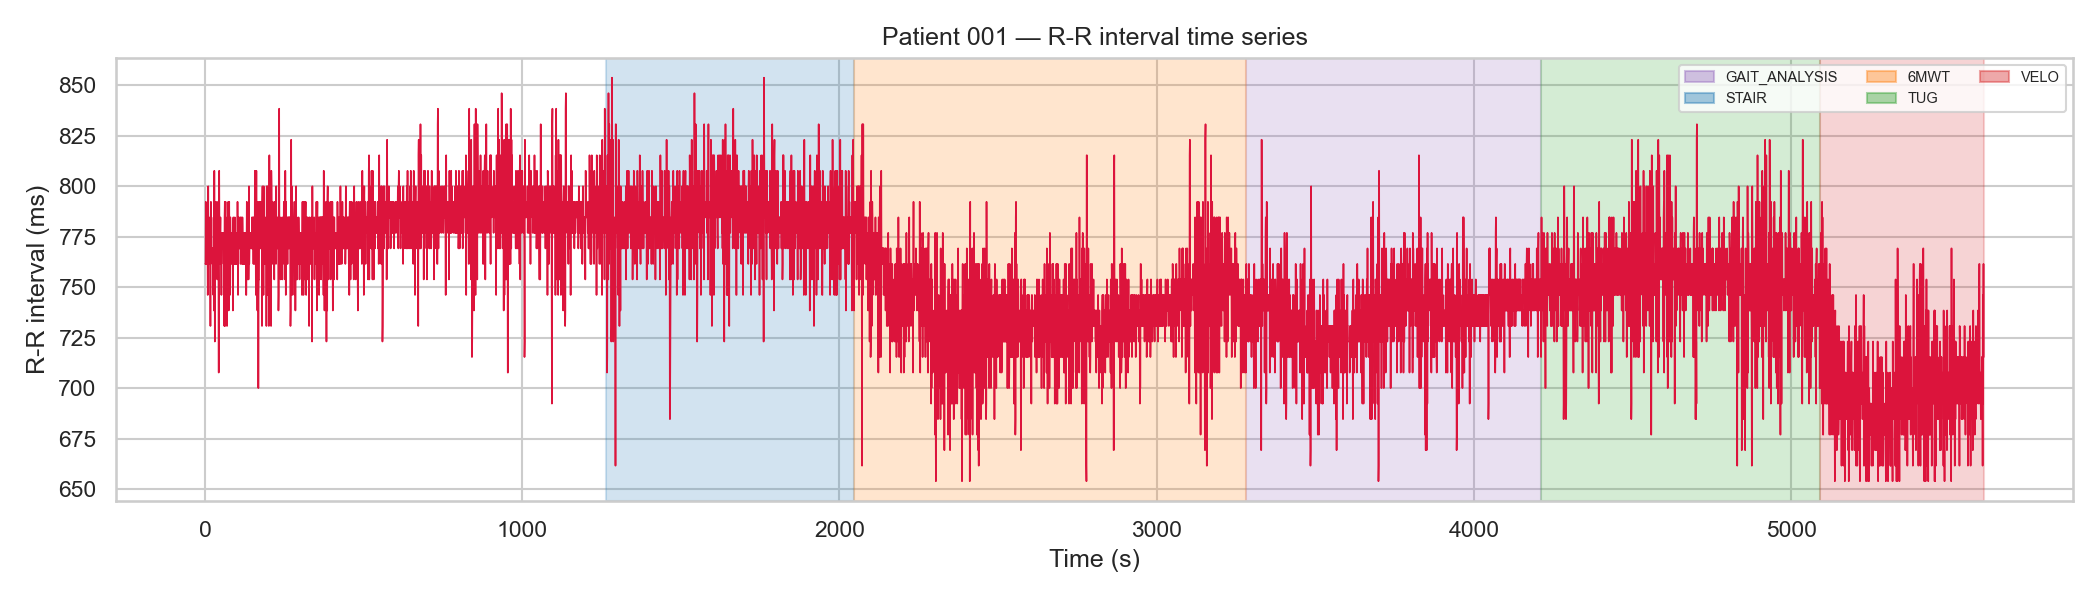

In [4]:
# Ricostruisco i segmenti dei test per sovrapporre il protocollo clinico alla dinamica beat-to-beat.
segments = get_test_segments(
    ecg['ann_samples'], ecg['ann_labels'],
    acc['ann_samples'], acc['ann_labels'],
    len(ecg['signal']), len(acc['signal_x']))
# Il grafico degli R-R nel tempo ? utile per vedere accelerazioni e recuperi della frequenza cardiaca.
plot_rr_timeseries(ecg_prep['rr_ms'], ecg_prep['rr_samples'], ecg['fs'],
    test_segments=segments, output_path='../results/figures/rr_001.png', patient_id='001')
# Mostro l'immagine finale gi? salvata per poterla riusare facilmente anche nella tesi scritta.
from IPython.display import Image; Image('../results/figures/rr_001.png')


## 4. ACC ? grezzo, componente gravitazionale, componente dinamica

Per l'accelerometro distinguere componente gravitazionale e componente dinamica ? molto utile: la prima ? legata soprattutto all'orientamento del corpo, la seconda al movimento effettivo. In riabilitazione questa separazione aiuta a capire se un aumento del segnale dipende da attivit? motoria o solo da cambi posturali.


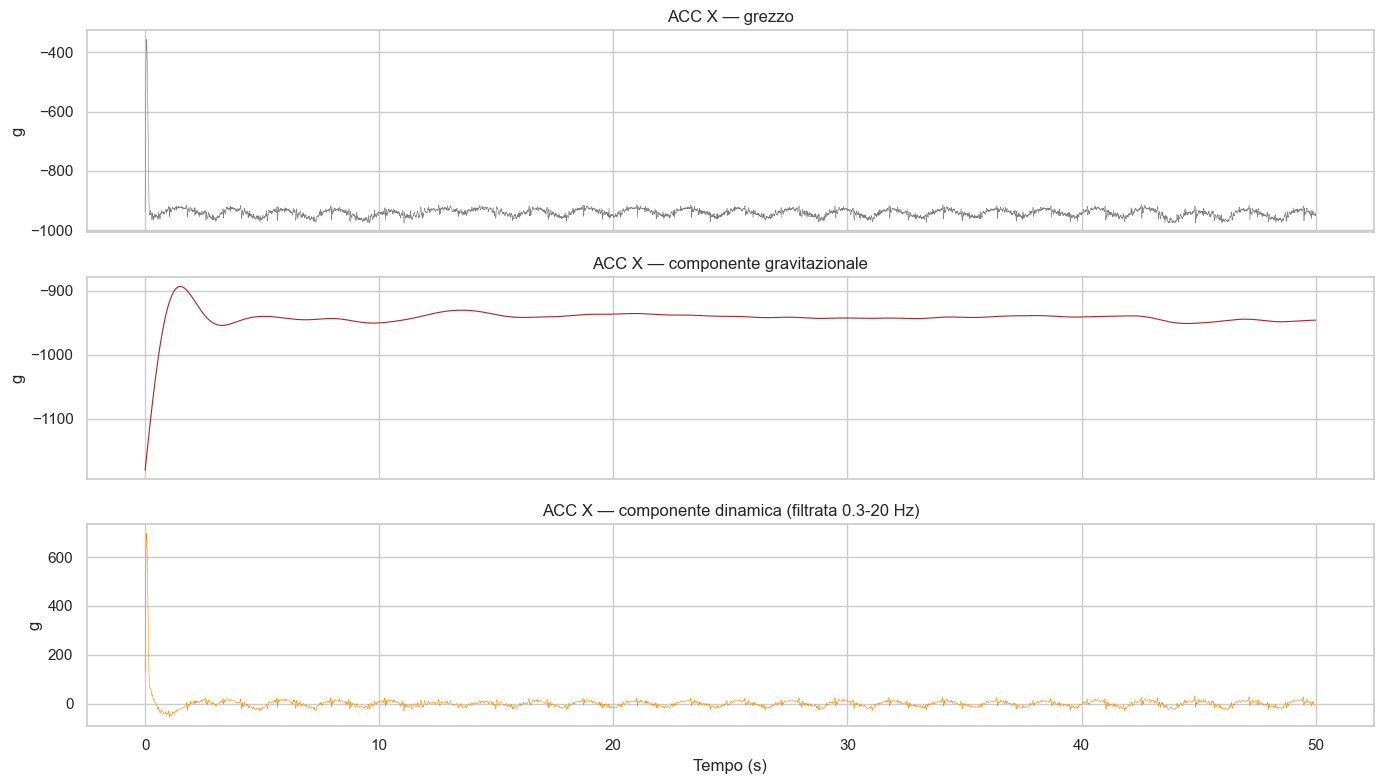

In [5]:
# Preprocesso i tre assi dell'ACC per separare orientamento e movimento attivo.
acc_prep = preprocess_acc(acc['signal_x'], acc['signal_y'], acc['signal_z'], acc['fs'])
# Uso una finestra iniziale abbastanza lunga da mostrare sia oscillazioni lente sia variazioni pi? rapide.
t_acc = np.arange(10000) / acc['fs']
# Metto le tre rappresentazioni in colonna per seguire l'effetto del preprocessing sullo stesso intervallo temporale.
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t_acc, acc['signal_x'][:10000], lw=0.4, color='grey')
axes[0].set_title('ACC X ? grezzo'); axes[0].set_ylabel('g')
# La componente gravitazionale dovrebbe variare lentamente, riflettendo soprattutto la postura del soggetto.
axes[1].plot(t_acc, acc_prep['gravity_x'][:10000], lw=0.8, color='firebrick')
axes[1].set_title('ACC X ? componente gravitazionale'); axes[1].set_ylabel('g')
# La componente dinamica mette invece in evidenza il contenuto informativo utile a quantificare il movimento.
axes[2].plot(t_acc, acc_prep['x_dynamic'][:10000], lw=0.4, color='darkorange')
axes[2].set_title('ACC X ? componente dinamica (filtrata 0.3-20 Hz)'); axes[2].set_ylabel('g')
axes[2].set_xlabel('Tempo (s)')
plt.tight_layout(); plt.show()


## 5. Magnitudine vettoriale ACC

La magnitudine vettoriale condensa l'informazione dei tre assi in una misura scalare pi? semplice da confrontare tra finestre temporali. ? una scelta molto comune perch? riduce la dipendenza dall'orientamento del sensore e fornisce un indicatore sintetico dell'intensit? del movimento.


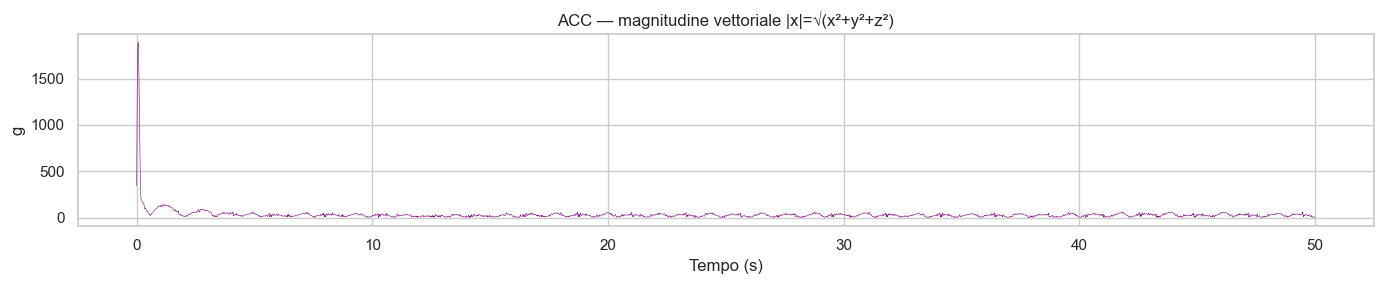

In [6]:
# Visualizzo la magnitudine per ottenere una misura unica dell'attivit? motoria complessiva.
fig, ax = plt.subplots(figsize=(14, 3))
# Combinare i tre assi in un solo tracciato rende pi? semplice confrontare finestre e livelli di attivazione.
ax.plot(t_acc, acc_prep['magnitude'][:10000], lw=0.4, color='purple')
ax.set_title('ACC ? magnitudine vettoriale |x|=?(x?+y?+z?)'); ax.set_ylabel('g')
ax.set_xlabel('Tempo (s)'); plt.tight_layout(); plt.show()
